# Translation Perturbation $\Delta y$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy
from sympy import Derivative, Matrix, Symbol

f = Symbol("f")
xc = Symbol("x_c")
yc = Symbol("y_c")

# Original camera pose
phi = Symbol("phi")  # Roll
theta = Symbol("theta")  # Pitch
psi = Symbol("psi")  # Yaw
x = Symbol("x")
y = Symbol("y")
# Non-zero otherwise degenerate homography since camera center aligned with plane
z = Symbol("z", nonzero=True)

# Viewpoint delta
dphi = Symbol("\Delta\phi")  # Roll
dtheta = Symbol("\Delta\\theta")  # Pitch
dpsi = Symbol("\Delta\psi")  # Yaw
dx = Symbol("\Delta x")
dy = Symbol("\Delta y")
dz = Symbol("\Delta z")

## Define homography matrix

In [2]:
H_inv = Matrix([[1, -dy / z, dy * yc / f], [0, 1, 0], [0, 0, 1]])
H_inv

Matrix([
[1, -\Delta y/z, \Delta y*y_c/f],
[0,           1,              0],
[0,           0,              1]])

## Apply projective transform

In [3]:
u = Symbol("u")
v = Symbol("v")

p0 = H_inv @ Matrix([u, v, 1])
p0 = p0 / p0[2]  # Normalize for non-homogeneous coordinates
p0 = sympy.simplify(p0)

u0 = p0[0]
v0 = p0[1]

In [4]:
u0

-\Delta y*v/z + \Delta y*y_c/f + u

In [5]:
v0

v

## Compute gradient

In [6]:
du0_dK = Derivative(u0, dy, evaluate=True).simplify()
du0_dK

-v/z + y_c/f

In [7]:
dv0_dK = Derivative(v0, dy, evaluate=True).simplify()
dv0_dK

0

## Compute gradient derivative

In [8]:
Derivative(du0_dK, dy, evaluate=True).simplify()

0

In [9]:
Derivative(dv0_dK, dy, evaluate=True).simplify()

0

## Plots

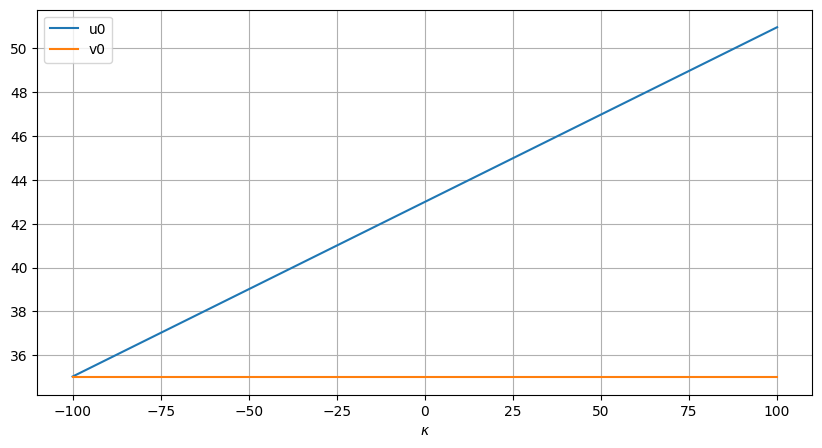

In [10]:
k_values = np.deg2rad(np.linspace(-100, 100, 1000))

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, z: -10, u: 43, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, z: -10, u: 43, v: 35})

u0_values = [u0_subs.subs({dy: val}).evalf() for val in k_values]
v0_values = [v0_subs.subs({dy: val}).evalf() for val in k_values]

u0_values = np.array(u0_values, dtype=float)
v0_values = np.array(v0_values, dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(np.rad2deg(k_values), u0_values, label="u0")
plt.plot(np.rad2deg(k_values), v0_values, label="v0")
plt.xlabel(r"$\kappa$")
plt.legend()
plt.grid(True)
plt.show()